## How Autoencoders work - Understanding the math and implementation

### Contents 

<ul>
<li>1. Introduction</li>
<ul>
    <li>1.1 What are Autoencoders ? </li>
    <li>1.2 How Autoencoders Work ? </li>
</ul>
<li>2. Implementation and UseCases</li>
<ul>
    <li>2.1 UseCase 1: Image Reconstruction </li>
    <li>2.2 UseCase 2: Noise Removal </li>
</ul>
</ul>

<br>

## 1. Introduction
## 1.1 What are Autoencoders 

Autoencoders are a special type of neural network architectures in which the output is same as the input. Autoencoders are trained in an unsupervised manner in order to learn the exteremely low level repersentations of the input data. These low level features are then deformed back to project the actual data. An autoencoder is a regression task where the network is asked to predict its input (in other words, model the identity function). These networks has a tight bottleneck of a few neurons in the middle, forcing them to create effective representations that compress the input into a low-dimensional code that can be used by the decoder to reproduce the original input.

A typical autoencoder architecture comprises of three main components: 

- **Encoding Architecture :** The encoder architecture comprises of series of layers with decreasing number of nodes and ultimately reduces to a latent view repersentation.  
- **Latent View Repersentation :** Latent view repersents the lowest level space in which the inputs are reduced and information is preserved.  
- **Decoding Architecture :** The decoding architecture is the mirro image of the encoding architecture but in which number of nodes in every layer increases and ultimately outputs the similar (almost) input.  

![](https://i.imgur.com/Rrmaise.png)

A highly fine tuned autoencoder model should be able to reconstruct the same input which was passed in the first layer. In this kernel, I will walk you through the working of autoencoders and their implementation.  Autoencoders are widly used with the image data and some of their use cases are: 

- Dimentionality Reduction   
- Image Compression   
- Image Denoising   
- Image Generation    
- Feature Extraction  



## 1.2 How Autoencoders work 

Lets understand the mathematics behind autoencoders. The main idea behind autoencoders is to learn a low level repersenation of a high level dimentional data. Lets try to understand the encoding process with an example.  
Data compression is a big topic that’s used in computer vision, computer networks, computer architecture, and many other fields. The point of data compression is to convert our input into a smaller representation that we recreate, to a degree of quality. This smaller representation is what would be passed around, and, when anyone needed the original, they would reconstruct it from the smaller representation.

Consider a ZIP file. When we create a ZIP file, we compress our files so that they take up fewer bytes. Then we pass around that ZIP file. If we wanted to access the contents, we can uncompress the ZIP file, and reconstruct the contents from the ZIP file.

In another example, consider a JPEG image file. This is an example of a lossy format: when we compress a JPEG, we lose information about the original. If we uncompress it, then our reconstruction isn’t perfect. However, for JPEG, we can compress it down to a tenth of the original data without any noticeable loss in image quality!

Many techniques in the past have been hard-coded or use clever algorithms. Autoencoders are unsupervised neural networks that use machine learning to do this compression for us. There are many different kinds of autoencoders that we’re going to look at: vanilla autoencoders, deep autoencoders, deep autoencoders for vision. Finally, we’ll apply autoencoders for removing noise from images.

Vanilla Autoencoder
We’ll first discuss the simplest of autoencoders: the standard, run-of-the-mill autoencoder. Essentially, an autoencoder is a 2-layer neural network that satisfies the following conditions.

The hidden layer is smaller than the size of the input and output layer.
The input layer and output layer are the same size.


The hidden layer is compressed representation, and we learn two sets of weights (and biases) that encode our input data into the compressed representation and decode our compressed representation back into input space.

Notice that there are no labels! Our input and output are the same! But then what is our loss function? We have a simple Euclidean distance loss: ||\mathbf{x} - \mathbf{\hat{x}}||^2 called the reconstruction error, where the input is \mathbf{x} and the reconstruction is \mathbf{\hat{x}}. We want to minimize this error. In other words, this error represents how close our reconstruction was to the true input data. We won’t expect a perfect reconstruction since the number of hidden neurons is less than the number of input neurons, but we want the parameters to give us the best possible reconstruction.

Mathematically, our above autoencoder can be thought of as two separate things: an encoder and decoder.
# #
where the superscripts correspond to the encoder and decoder and the input is \mathbf{x}. Hence, our loss function will be the squared Euclidean error.

When we train our autoencoder, we’re trying to minimize \mathcal{L}. We won’t see the backpropagation derivation of the update rules, but they’re identical to a standard neural network.
# #
The big catch with autoencoders is that they only work for the data we train them on! If we train our autoencoder on images of cats, then it won’t work too well for images of dogs!

This is all there is to autoencoders! They’re simple neural networks but also very powerful! Let’s code up an autoencoder.


## 2. Implementation

## 2.1 UseCase 1 : Image Reconstruction

1. Load the required libraries


In [1]:
## load the libraries 
from keras.layers import Dense, Input, Conv2D, LSTM, MaxPooling2D, UpSampling2D , Flatten ,MaxPool2D ,BatchNormalization , Dropout
from keras.optimizers import RMSprop ,Adam

from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from numpy import argmax, array_equal
import matplotlib.pyplot as plt
from keras.models import Model
from imgaug import augmenters
from random import randint
import pandas as pd
from keras.utils.np_utils import to_categorical

import numpy as np


Using TensorFlow backend.


### 2. Dataset Prepration 

Load the dataset, separate predictors and target, normalize the inputs.

In [2]:
### read dataset 
train = pd.read_csv("../input/fashion-mnist_train.csv")
train_x = train[list(train.columns)[1:]].values
train_y = train['label'].values

## normalize and reshape the predictors  
train_x = train_x / 255

## create train and validation datasets
train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size=0.2)

## reshape the inputs
train_x = train_x.reshape(-1, 784)
val_x = val_x.reshape(-1, 784)

### 3. Create Autoencoder architecture

In this section, lets create an autoencoder architecture. The encoding part comprises of three layers with 2000, 1200, and 500 nodes. Encoding architecture is connected to latent view space comprising of 10 nodes which is then connected to decoding architecture with 500, 1200, and 2000 nodes. The final layer comprises of exact number of nodes as the input layer.

In [3]:
## input layer
input_layer = Input(shape=(784,))

## encoding architecture
encode_layer1 = Dense(1500, activation='relu')(input_layer)
encode_layer2 = Dense(1000, activation='relu')(encode_layer1)
encode_layer3 = Dense(500, activation='relu')(encode_layer2)

## latent view
latent_view   = Dense(10, activation='sigmoid')(encode_layer3)

## decoding architecture
decode_layer1 = Dense(500, activation='relu')(latent_view)
decode_layer2 = Dense(1000, activation='relu')(decode_layer1)
decode_layer3 = Dense(1500, activation='relu')(decode_layer2)

## output layer
output_layer  = Dense(784)(decode_layer3)

model = Model(input_layer, output_layer)

Instructions for updating:
Colocations handled automatically by placer.


Here is the summary of our autoencoder architecture.

In [4]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 784)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 1500)              1177500   
_________________________________________________________________
dense_2 (Dense)              (None, 1000)              1501000   
_________________________________________________________________
dense_3 (Dense)              (None, 500)               500500    
_________________________________________________________________
dense_4 (Dense)              (None, 10)                5010      
_________________________________________________________________
dense_5 (Dense)              (None, 500)               5500      
_________________________________________________________________
dense_6 (Dense)              (None, 1000)              501000    
__________

Next, we will train the model with early stopping callback.

In [5]:
model.compile(optimizer='adam', loss='mse')
early_stopping = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=1, mode='auto')
model.fit(train_x, train_x, epochs=20, batch_size=2048, validation_data=(val_x, val_x), callbacks=[early_stopping])

Instructions for updating:
Use tf.cast instead.
Train on 48000 samples, validate on 12000 samples
Epoch 1/20
48000/48000 [==============================] - 4s 93us/step - loss: 0.0972 - val_loss: 0.0712
Epoch 2/20
48000/48000 [==============================] - 1s 18us/step - loss: 0.0646 - val_loss: 0.0573
Epoch 3/20
48000/48000 [==============================] - 1s 18us/step - loss: 0.0515 - val_loss: 0.0457
Epoch 4/20
48000/48000 [==============================] - 1s 19us/step - loss: 0.0416 - val_loss: 0.0388
Epoch 5/20
48000/48000 [==============================] - 1s 18us/step - loss: 0.0374 - val_loss: 0.0360
Epoch 6/20
48000/48000 [==============================] - 1s 18us/step - loss: 0.0341 - val_loss: 0.0321
Epoch 7/20
48000/48000 [==============================] - 1s 18us/step - loss: 0.0307 - val_loss: 0.0297
Epoch 8/20
48000/48000 [==============================] - 1s 18us/step - loss: 0.0276 - val_loss: 0.0265
Epoch 9/20
48000/48000 [==============================] - 1s 1

Generate the predictions on validation data. 

In [6]:
val_x.shape

(12000, 784)

In [7]:
preds = model.predict(val_x)

Lets plot the original and predicted image

**Inputs: Actual Images**

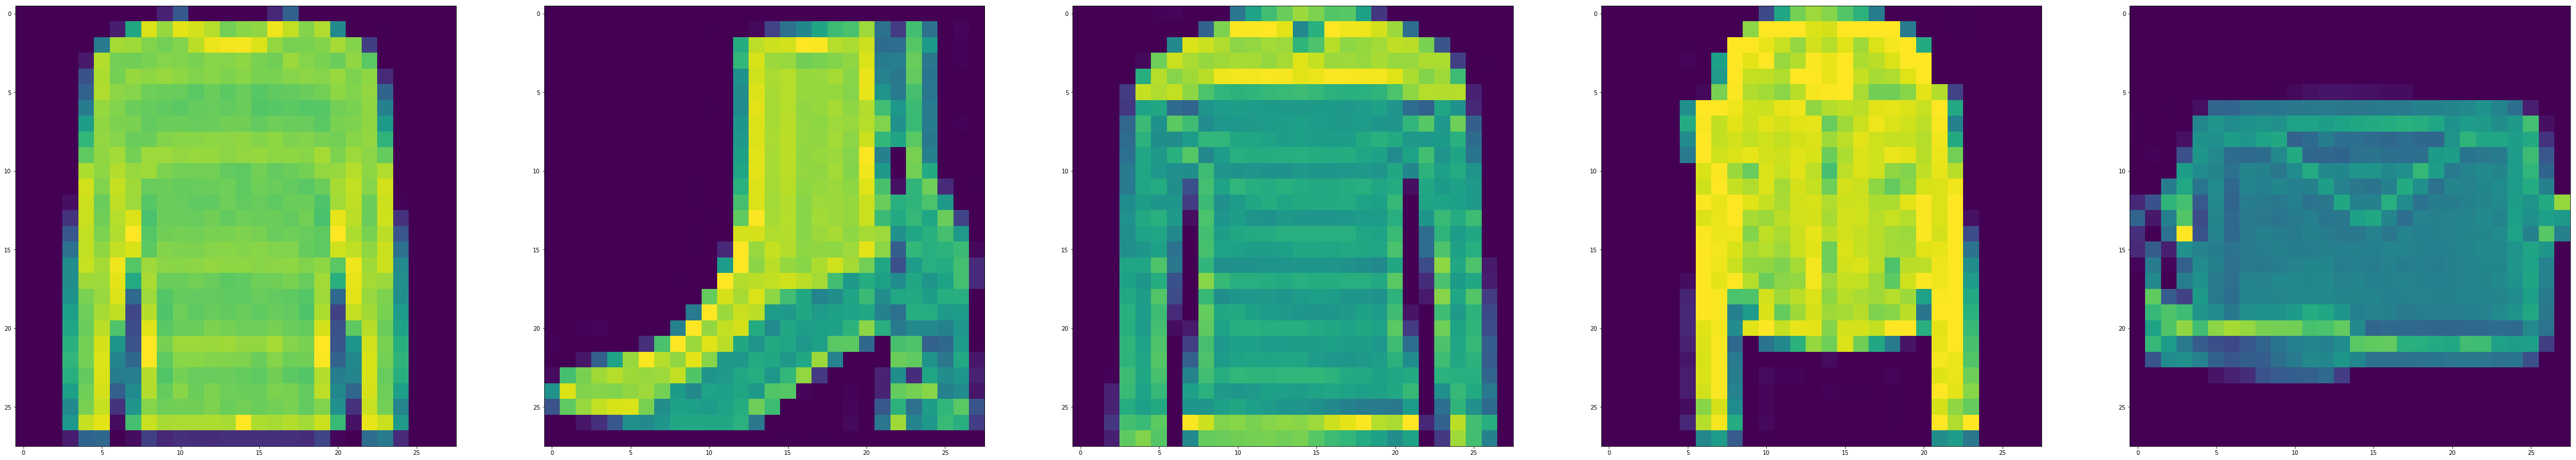

In [8]:
from PIL import Image 
f, ax = plt.subplots(1,5)
f.set_size_inches(80, 40)
for i in range(5):
    ax[i].imshow(val_x[i].reshape(28, 28))
plt.show()

**Predicted : Autoencoder Output**

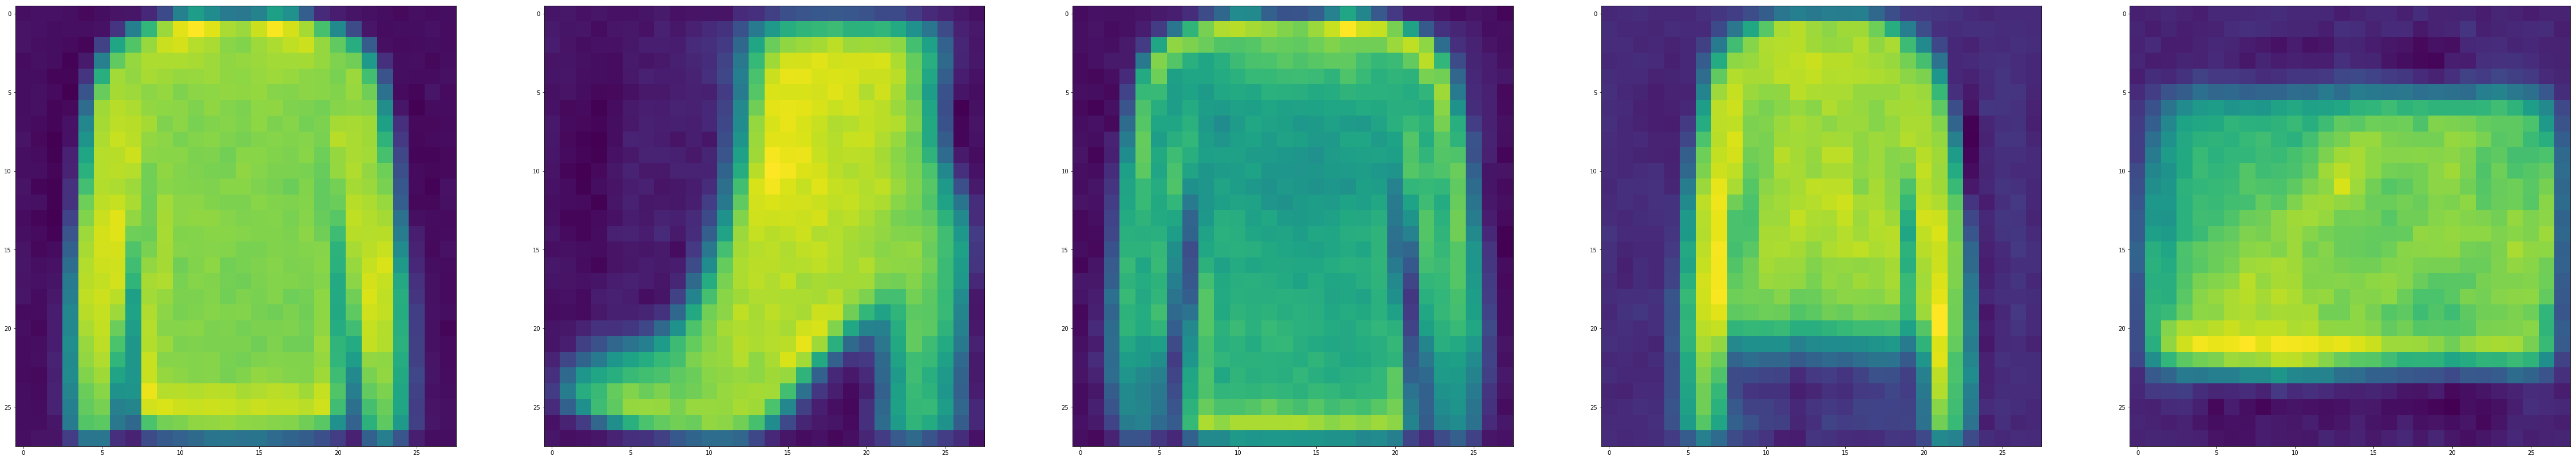

In [9]:
f, ax = plt.subplots(1,5)
f.set_size_inches(80, 40)
for i in range(5):
    ax[i].imshow(preds[i].reshape(28, 28))
plt.show()

So we can see that an autoencoder trained with 20 epoochs is able to reconstruct the input images very well. Lets look at other use-case of autoencoders - Image denoising or removal of noise from the image.  

## 2.2 UseCase 2 - Image Denoising

Autoencoders are pretty useful, lets look at another application of autoencoders - Image denoising. Many a times input images contain noise in the data, autoencoders can be used to get rid of those images. Lets see it in action. First lets prepare the train_x and val_x data contianing the image pixels. 

![](https://www.learnopencv.com/wp-content/uploads/2017/11/denoising-autoencoder-600x299.jpg)

In [10]:
## recreate the train_x array and val_x array
train_x = train[list(train.columns)[1:]].values
train_x,valid_x,train_ground,valid_ground = train_test_split(train_x, train_x,test_size=0.2,random_state=13)

## normalize and reshape
train_x = train_x/255.
valid_x = valid_x/255.
train_ground = train_ground/255.
valid_ground = valid_ground/255.

In this autoencoder network, we will add convolutional layers because convolutional networks works really well with the image inputs. To apply convolutions on image data, we will reshape our inputs in the form of 28 * 28 matrix. 

In [11]:
train_x = train_x.reshape(-1, 28, 28, 1)
valid_x = valid_x.reshape(-1, 28, 28, 1)
train_ground = train_ground.reshape(-1, 28, 28, 1)
valid_ground = valid_ground.reshape(-1, 28, 28, 1)

### Noisy Images 

We can intentionally introduce the noise in an image. I am using imaug package which can be used to augment the images with different variations. One such variation can be introduction of noise. Different types of noises can be added to the images. For example: 

- Salt and Pepper Noise  
- Gaussian Noise  
- Periodic Noise  
- Speckle Noise  

Lets introduce salt and pepper noise to our data which is also known as impulse noise. This noise introduces sharp and sudden disturbances in the image signal. It presents itself as sparsely occurring white and black pixels. 


In [12]:
# Lets add sample noise - Salt and Pepper
noise = augmenters.SaltAndPepper(0.1)
seq_object = augmenters.Sequential([noise])

train_x_n = seq_object.augment_images(train_x * 255) / 255
val_x_n = seq_object.augment_images(valid_x * 255) / 255

Before adding noise

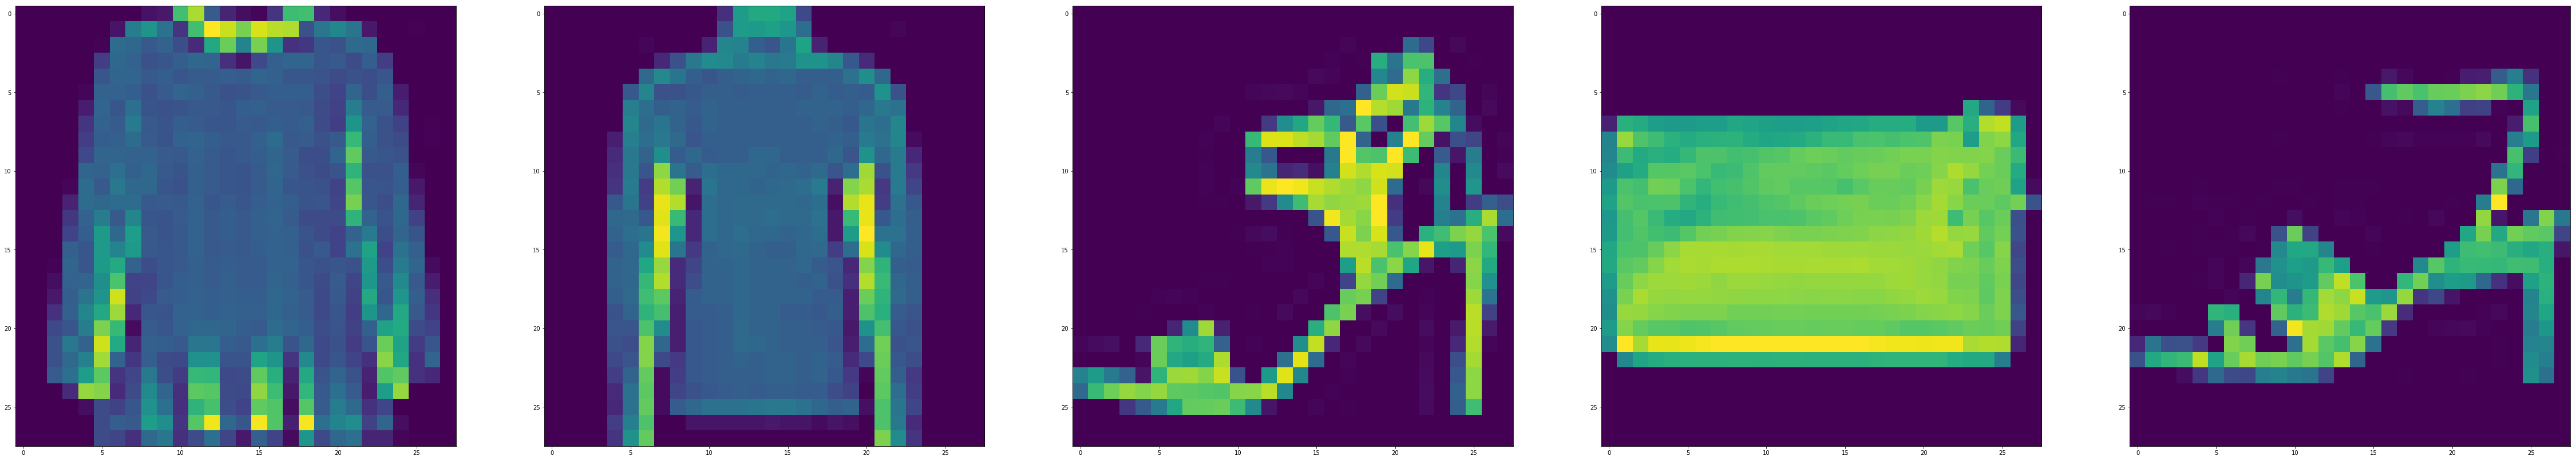

In [13]:
f, ax = plt.subplots(1,5)
f.set_size_inches(80, 40)
for i in range(5,10):
    ax[i-5].imshow(train_x[i].reshape(28, 28))
plt.show()

After adding noise

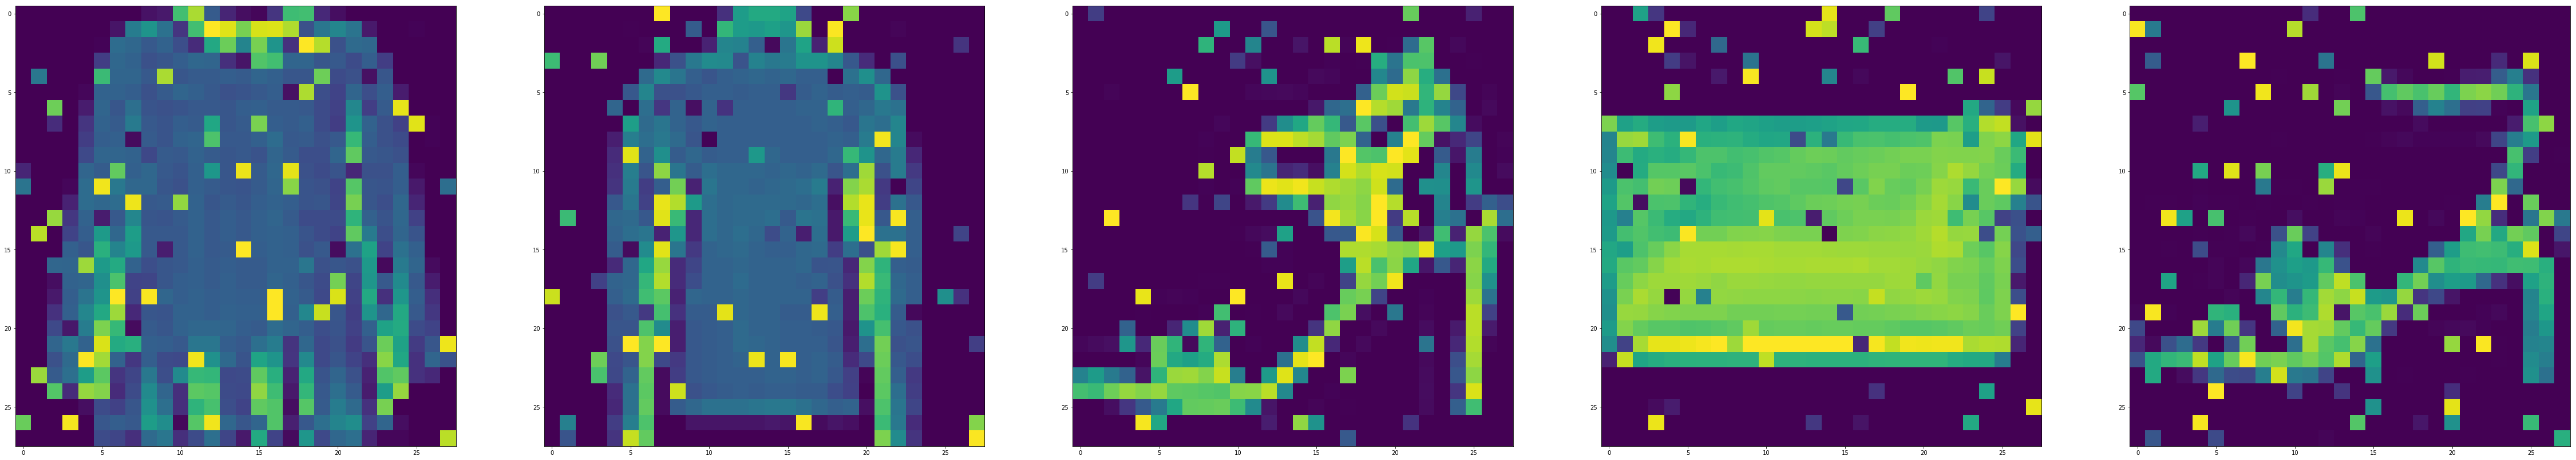

In [14]:
f, ax = plt.subplots(1,5)
f.set_size_inches(80, 40)
for i in range(5,10):
    ax[i-5].imshow(train_x_n[i].reshape(28, 28))
plt.show()

Lets now create the model architecture for the autoencoder. Lets understand what type of network needs to be created for this problem. 

**Encoding Architecture:**   

The encoding architure is composed of 3 Convolutional Layers and 3 Max Pooling Layers stacked one by one. Relu is used as the activation function in the convolution layers and padding is kept as "same". Role of max pooling layer is to downsample the image dimentions. This layer applies a max filter to non-overlapping subregions of the initial representation.  

**Decoding Architecture:**   

Similarly in decoding architecture, the convolution layers will be used having same dimentions (in reverse manner) as the encoding architecture. But instead of 3 maxpooling layers, we will be adding 3 upsampling layers. Again the activation function will be same (relu), and padding in convolution layers will be same as well.  Role of upsampling layer is to upsample the dimentions of a input vector to a higher resolution / dimention. The max pooling operation is non-invertible, however an approximate inverse can be obtained by recording the locations of the maxima within each pooling region. Umsampling layers make use of this property to project the reconstructions from a low dimentional feature space.   



In [15]:
# input layer
input_layer = Input(shape=(28, 28, 1))

# encoding architecture
encoded_layer1 = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)
encoded_layer1 = MaxPool2D( (2, 2), padding='same')(encoded_layer1)
encoded_layer2 = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded_layer1)
encoded_layer2 = MaxPool2D( (2, 2), padding='same')(encoded_layer2)
encoded_layer3 = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded_layer2)
latent_view    = MaxPool2D( (2, 2), padding='same')(encoded_layer3)

# decoding architecture
decoded_layer1 = Conv2D(16, (3, 3), activation='relu', padding='same')(latent_view)
decoded_layer1 = UpSampling2D((2, 2))(decoded_layer1)
decoded_layer2 = Conv2D(32, (3, 3), activation='relu', padding='same')(decoded_layer1)
decoded_layer2 = UpSampling2D((2, 2))(decoded_layer2)
decoded_layer3 = Conv2D(64, (3, 3), activation='relu')(decoded_layer2)
decoded_layer3 = UpSampling2D((2, 2))(decoded_layer3)
output_layer   = Conv2D(1, (3, 3), padding='same')(decoded_layer3)

# compile the model
model_2 = Model(input_layer, output_layer)
model_2.compile(optimizer='adam', loss='mse')

Here is the model summary

In [16]:
model_2.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 28, 28, 1)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        640       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 14, 14, 32)        18464     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 7, 7, 32)          0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 7, 7, 16)          4624      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 4, 4, 16)          0         
__________

Train the model with early stopping callback. Increase the number of epochs to a higher number for better results. 

In [17]:
early_stopping = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=5, mode='auto')
history = model_2.fit(train_x_n, train_x, epochs=10, batch_size=2048, validation_data=(val_x_n, valid_x), callbacks=[early_stopping])

Train on 48000 samples, validate on 12000 samples
Epoch 1/10
48000/48000 [==============================] - 5s 114us/step - loss: 0.0809 - val_loss: 0.0521
Epoch 2/10
48000/48000 [==============================] - 2s 42us/step - loss: 0.0422 - val_loss: 0.0363
Epoch 3/10
48000/48000 [==============================] - 2s 42us/step - loss: 0.0333 - val_loss: 0.0305
Epoch 4/10
48000/48000 [==============================] - 2s 43us/step - loss: 0.0284 - val_loss: 0.0266
Epoch 5/10
48000/48000 [==============================] - 2s 43us/step - loss: 0.0253 - val_loss: 0.0244
Epoch 6/10
48000/48000 [==============================] - 2s 42us/step - loss: 0.0237 - val_loss: 0.0233
Epoch 7/10
48000/48000 [==============================] - 2s 42us/step - loss: 0.0225 - val_loss: 0.0222
Epoch 8/10
48000/48000 [==============================] - 2s 43us/step - loss: 0.0215 - val_loss: 0.0213
Epoch 9/10
48000/48000 [==============================] - 2s 42us/step - loss: 0.0207 - val_loss: 0.0206
Epoc

In [18]:
preds = model_2.predict(val_x_n)

# noisefull images in validation set

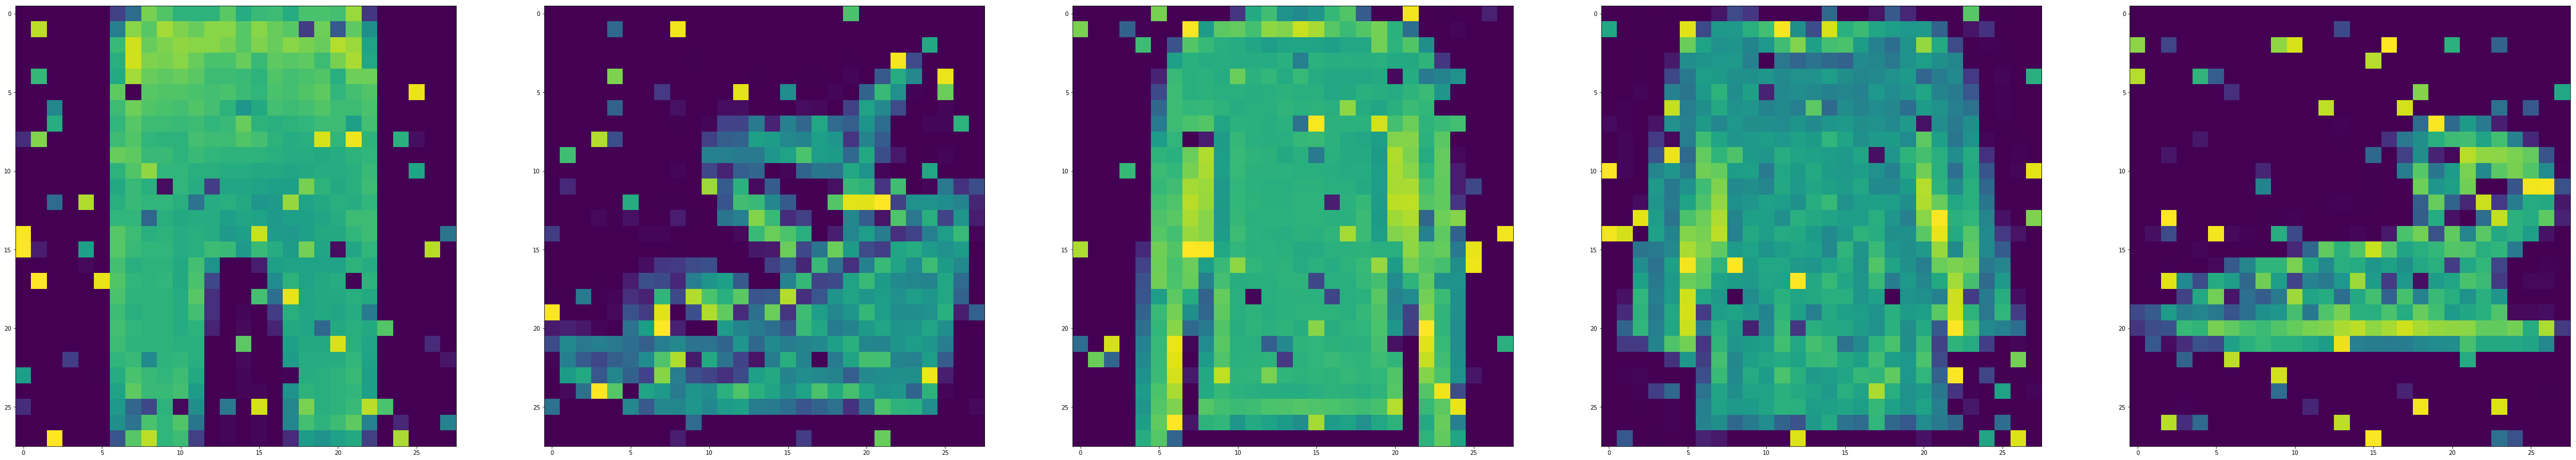

In [19]:
f, ax = plt.subplots(1,5)
f.set_size_inches(80, 40)
for i in range(5):
    ax[i].imshow(val_x_n[i].reshape(28, 28))
plt.show()

# image resconstructed from noisefull images

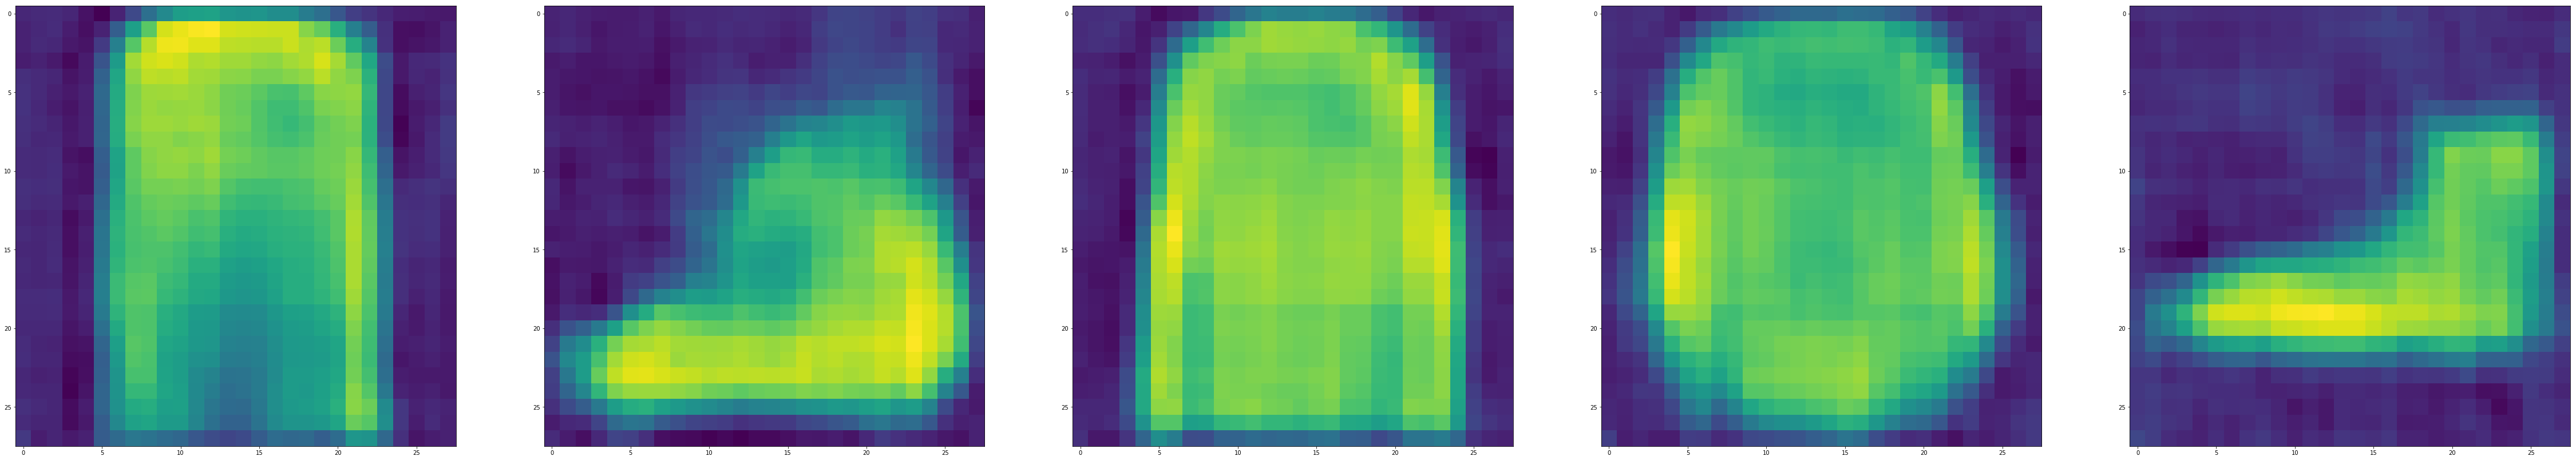

In [20]:
f, ax = plt.subplots(1,5)
f.set_size_inches(80, 40)
for i in range(5):
    ax[i].imshow(preds[i].reshape(28, 28))
plt.show()

## Till now we have learnt how to develop autoencoder from scrath not the basic but also a deep one , we understand architecture required to build that 
## So now from here we will start how we can use Auto Encoder we can use to classify images in 10 categories

## but again question arises how we will do it ? but before that why we are doing so ? what is the need ? CNN is not efficient do so ?
## Previously i have made kernel how we can use PCA with CNN now the reason behind to use that is just an expriment that if we can use most important feautres of images by converting images in nxn matrix and can achieve near about accuracy with less features 
## one more reason in kaggle world people do ensemble , without taking care scalibilty of application so might be model is producing good number but not good in production environment 
## with pca-cnn our goal is accuracy and making model more optimized , so i achieved it 

## so now we are taking autoencoders for following reasons:
### 1> firt itself is neural network architecture it will learn more complex features than PCA which learnt only linearities.
### 2> second pca was usefull for grayscale images but not for RGB data reason behind non-linearities and if data is complex PCA alone can't do make it possible here we are using fashion mnist but in next commit RGB data will be there to classify 
### 3>model optimization , making the use less number of parameters and achieve a good accuracy  

![](https://www.spiedigitallibrary.org/ContentImages/Journals/JEIME5/25/2/023018/FigureImages/JEI_25_2_023018_f001.png)

## it is very simple most the people will understand by seeing which layer of autoencoder we will be using pass to the CNN ? 

## answer is simple that encoder layer we will be using passing to top layer of CNN 
## we will freeze the layers before CNN becuse encoder is already trained . 

## so shape of our data -> then build encoder layer ->pass it to CNN let's see how we can do it 

In [21]:
### read dataset 
train = pd.read_csv("../input/fashion-mnist_train.csv")
test  = pd.read_csv("../input/fashion-mnist_test.csv")
train_x = train[list(train.columns)[1:]].values
train_y = train['label'].values
test_y=test["label"].values
test=test[list(test.columns)[1:]].values


## normalize and reshape the predictors  
train_x = train_x / 255
test= test/255

## create train and validation datasets
#train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size=0.2)

## reshape the inputs
train_x = train_x.reshape(-1, 28,28,1)
test = test.reshape(-1, 28,28,1)

In [22]:
train_x.shape , test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

small dictionary for showing pics in dataset 

In [23]:
label_dict = {
 0: 'A',
 1: 'B',
 2: 'C',
 3: 'D',
 4: 'E',
 5: 'F',
 6: 'G',
 7: 'H',
 8: 'I',
 9: 'J',
}

Text(0.5, 1.0, '(Label: A)')

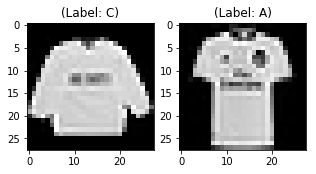

In [24]:

plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
curr_img = np.reshape(train_x[0], (28,28))
curr_lbl = train_y[0]
plt.imshow(curr_img, cmap='gray')
plt.title("(Label: " + str(label_dict[curr_lbl]) + ")")

# Display the first image in testing data
plt.subplot(122)
curr_img = np.reshape(test[0], (28,28))
curr_lbl = test_y[0]
plt.imshow(curr_img, cmap='gray')
plt.title("(Label: " + str(label_dict[curr_lbl]) + ")")

In [25]:
from sklearn.model_selection import train_test_split
train_X,valid_X,train_ground,valid_ground = train_test_split(train_x,
                                                             train_x,
                                                             test_size=0.2,
                                                             random_state=13)

In [26]:
batch_size = 64
epochs = 200
inChannel = 1
x, y = 28, 28
input_img = Input(shape = (x, y, inChannel))
num_classes = 10

# Encoder Architecture , first we will train our autoencoder then we will use our encoder layer after to pass it's output to Dense layers

In [27]:
def encoder(input_img):
    #encoder
    #input = 28 x 28 x 1 (wide and thin)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img) #28 x 28 x 32
    conv1 = BatchNormalization()(conv1)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1) #14 x 14 x 32
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1) #14 x 14 x 64
    conv2 = BatchNormalization()(conv2)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2) #7 x 7 x 64
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2) #7 x 7 x 128 (small and thick)
    conv3 = BatchNormalization()(conv3)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    conv3 = BatchNormalization()(conv3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv3) #7 x 7 x 256 (small and thick)
    conv4 = BatchNormalization()(conv4)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    conv4 = BatchNormalization()(conv4)
    return conv4

def decoder(conv4):    
    #decoder
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv4) #7 x 7 x 128
    conv5 = BatchNormalization()(conv5)
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv5)
    conv5 = BatchNormalization()(conv5)
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv5) #7 x 7 x 64
    conv6 = BatchNormalization()(conv6)
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv6)
    conv6 = BatchNormalization()(conv6)
    up1 = UpSampling2D((2,2))(conv6) #14 x 14 x 64
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(up1) # 14 x 14 x 32
    conv7 = BatchNormalization()(conv7)
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv7)
    conv7 = BatchNormalization()(conv7)
    up2 = UpSampling2D((2,2))(conv7) # 28 x 28 x 32
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(up2) # 28 x 28 x 1
    return decoded


In [28]:
autoencoder = Model(input_layer, decoder(encoder(input_layer)))
autoencoder.compile(loss='mean_squared_error', optimizer = 'rmsprop')

## Let's visualize the layers that you created in the above step by using the summary function. This will show a number of parameters (weights and biases) in each layer and also the total parameters in your model.

In [29]:
autoencoder.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 28, 28, 1)         0         
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 28, 28, 32)        320       
_________________________________________________________________
batch_normalization_1 (Batch (None, 28, 28, 32)        128       
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
batch_normalization_2 (Batch (None, 28, 28, 32)        128       
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 14, 14, 64)        18496     
__________

let's first train our autoencoder then we can use it for classification  

In [30]:
autoencoder_train = autoencoder.fit(train_X, train_ground, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_X, valid_ground))

Train on 48000 samples, validate on 12000 samples
Epoch 1/200
48000/48000 [==============================] - 17s 352us/step - loss: 0.0192 - val_loss: 0.0125
Epoch 2/200
48000/48000 [==============================] - 14s 288us/step - loss: 0.0090 - val_loss: 0.0159
Epoch 3/200
48000/48000 [==============================] - 14s 288us/step - loss: 0.0070 - val_loss: 0.0081
Epoch 4/200
48000/48000 [==============================] - 14s 287us/step - loss: 0.0055 - val_loss: 0.0056
Epoch 5/200
48000/48000 [==============================] - 14s 288us/step - loss: 0.0047 - val_loss: 0.0045
Epoch 6/200
48000/48000 [==============================] - 14s 290us/step - loss: 0.0042 - val_loss: 0.0062
Epoch 7/200
48000/48000 [==============================] - 15s 311us/step - loss: 0.0038 - val_loss: 0.0033
Epoch 8/200
48000/48000 [==============================] - 14s 297us/step - loss: 0.0035 - val_loss: 0.0035
Epoch 9/200
48000/48000 [==============================] - 14s 298us/step - loss: 0.00

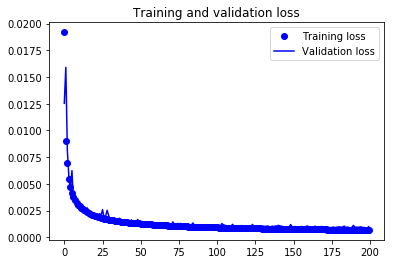

In [31]:
loss = autoencoder_train.history['loss']
val_loss = autoencoder_train.history['val_loss']
epochs = range(200)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [32]:
autoencoder.save_weights('autoencoder.h5')

In [33]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_y)
test_Y_one_hot = to_categorical(test_y)

# Display the change for category label using one-hot encoding
print('Original label:', train_y[1000])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 8
After conversion to one-hot: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [34]:
train_X,valid_X,train_label,valid_label = train_test_split(train_x,train_Y_one_hot,test_size=0.2,random_state=13)


In [35]:
train_X.shape , valid_X.shape , train_label.shape , valid_label.shape

((48000, 28, 28, 1), (12000, 28, 28, 1), (48000, 10), (12000, 10))

## i have changed the neural architecture from taking dense (128) to two stacked dense (50) and dense(30) with dropout(0.1) to reduce overfitting and make the model generalized for fashion mnist dataset 

In [36]:
def fc(enco):
    flat = Flatten()(enco)
    x = Dense(50, activation='relu')(flat)
    x = Dropout(0.1)(x)
    x = Dense(30, activation='relu')(x)
    x = Dropout(0.1)(x)

    out = Dense(10, activation='softmax')(x)
    return out

In [37]:
encode = encoder(input_layer)
full_model = Model(input_layer,fc(encode))


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


## Note: The next step is pretty important. In order to be sure whether the weights of the encoder part of the autoencoder are similar to the weights you loaded to the encoder function of the classification model, you should always print any one of the same layers weights of both the models. If they are not similar, then there is no use in using the autoencoder classification strategy.

In [38]:
for l1,l2 in zip(full_model.layers[:19],autoencoder.layers[0:19]):
    l1.set_weights(l2.get_weights())


In [39]:
autoencoder.get_weights()[0][1]


array([[[-0.08550048, -0.5166691 ,  0.166785  , -1.338099  ,
          0.10743106, -0.01924266,  0.00535823,  0.16270192,
          0.14262804, -0.10600711, -0.55194604,  0.14360365,
         -0.5623424 , -0.6849645 ,  0.34646976,  0.9594217 ,
          0.5895347 ,  0.32237798,  0.28732327,  0.06010443,
          0.70022804, -0.8092159 ,  0.16793922, -0.45773113,
         -1.347543  ,  0.03924499, -0.07227701,  0.11234499,
          0.52032506,  0.1474429 , -0.24904086, -0.7491441 ]],

       [[-0.19844529, -0.56907266,  0.53201824, -0.57103276,
          0.58073205, -0.38495764,  0.5307561 , -0.16584457,
          0.9133569 ,  0.29372084,  0.73280066,  0.6158424 ,
         -1.2112973 ,  0.17574582, -0.408847  ,  0.02067897,
          0.16198099, -0.49806786,  0.2713582 ,  0.17787176,
         -0.27719787, -0.82025194, -0.7738727 , -1.0216764 ,
          0.08840085, -0.17611091,  0.7456008 , -0.36983413,
         -0.6319775 ,  0.664963  , -0.76308894, -1.0788672 ]],

       [[ 0.359891

In [40]:
full_model.get_weights()[0][1]


array([[[-0.08550048, -0.5166691 ,  0.166785  , -1.338099  ,
          0.10743106, -0.01924266,  0.00535823,  0.16270192,
          0.14262804, -0.10600711, -0.55194604,  0.14360365,
         -0.5623424 , -0.6849645 ,  0.34646976,  0.9594217 ,
          0.5895347 ,  0.32237798,  0.28732327,  0.06010443,
          0.70022804, -0.8092159 ,  0.16793922, -0.45773113,
         -1.347543  ,  0.03924499, -0.07227701,  0.11234499,
          0.52032506,  0.1474429 , -0.24904086, -0.7491441 ]],

       [[-0.19844529, -0.56907266,  0.53201824, -0.57103276,
          0.58073205, -0.38495764,  0.5307561 , -0.16584457,
          0.9133569 ,  0.29372084,  0.73280066,  0.6158424 ,
         -1.2112973 ,  0.17574582, -0.408847  ,  0.02067897,
          0.16198099, -0.49806786,  0.2713582 ,  0.17787176,
         -0.27719787, -0.82025194, -0.7738727 , -1.0216764 ,
          0.08840085, -0.17611091,  0.7456008 , -0.36983413,
         -0.6319775 ,  0.664963  , -0.76308894, -1.0788672 ]],

       [[ 0.359891

## so both are having same weights

In [41]:
for layer in full_model.layers[0:19]:
    layer.trainable = False


In [42]:
full_model.compile(loss="categorical_crossentropy", optimizer=Adam(lr=1e-5),metrics=['accuracy'])


In [43]:
full_model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 28, 28, 1)         0         
_________________________________________________________________
conv2d_23 (Conv2D)           (None, 28, 28, 32)        320       
_________________________________________________________________
batch_normalization_15 (Batc (None, 28, 28, 32)        128       
_________________________________________________________________
conv2d_24 (Conv2D)           (None, 28, 28, 32)        9248      
_________________________________________________________________
batch_normalization_16 (Batc (None, 28, 28, 32)        128       
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_25 (Conv2D)           (None, 14, 14, 64)        18496     
__________

In [44]:
classify_train = full_model.fit(train_X, train_label, batch_size=64,epochs=40,verbose=1,validation_data=(valid_X, valid_label))


Train on 48000 samples, validate on 12000 samples
Epoch 1/40
48000/48000 [==============================] - 6s 123us/step - loss: 1.1817 - acc: 0.6089 - val_loss: 0.5946 - val_acc: 0.8239
Epoch 2/40
48000/48000 [==============================] - 5s 99us/step - loss: 0.6570 - acc: 0.7898 - val_loss: 0.4629 - val_acc: 0.8547
Epoch 3/40
48000/48000 [==============================] - 5s 108us/step - loss: 0.5428 - acc: 0.8263 - val_loss: 0.4059 - val_acc: 0.8679
Epoch 4/40
48000/48000 [==============================] - 5s 106us/step - loss: 0.4777 - acc: 0.8446 - val_loss: 0.3703 - val_acc: 0.8771
Epoch 5/40
48000/48000 [==============================] - 5s 99us/step - loss: 0.4330 - acc: 0.8600 - val_loss: 0.3471 - val_acc: 0.8867
Epoch 6/40
48000/48000 [==============================] - 5s 99us/step - loss: 0.3996 - acc: 0.8707 - val_loss: 0.3292 - val_acc: 0.8924
Epoch 7/40
48000/48000 [==============================] - 5s 99us/step - loss: 0.3742 - acc: 0.8787 - val_loss: 0.3173 - val_

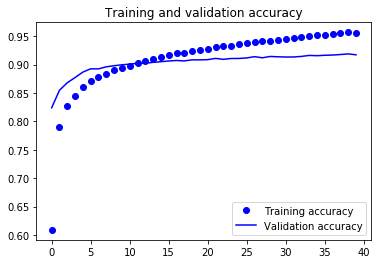

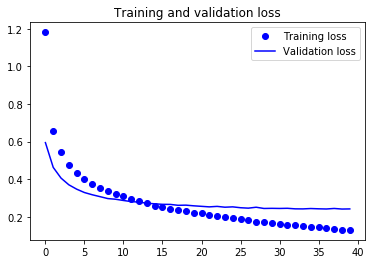

In [45]:
accuracy = classify_train.history['acc']
val_accuracy = classify_train.history['val_acc']
loss = classify_train.history['loss']
val_loss = classify_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

## Model Evaluation on the Test Set
Finally, let's also evaluate your model on test data and see how it performs!

In [46]:
test_eval = full_model.evaluate(test, test_Y_one_hot, verbose=0)

In [47]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])


Test loss: 0.22951916920244694
Test accuracy: 0.924


## Predicted Labels

In [48]:
predicted_classes = full_model.predict(test)


Since the predictions you get are floating point values, it will not be feasible to compare the predicted labels with true test labels. So, you will round off the output which will convert the float values into an integer. Further, you will use np.argmax() to select the index number which has a higher value in a row.

For example, let's assume a prediction for one test image to be [0 1 0 0 0 0 0 0 0 0], the output for this should be a class label 1.

In [49]:
predicted_classes = np.argmax(np.round(predicted_classes),axis=1)


In [50]:
predicted_classes.shape, test_y.shape

((10000,), (10000,))

Found 9195 correct labels


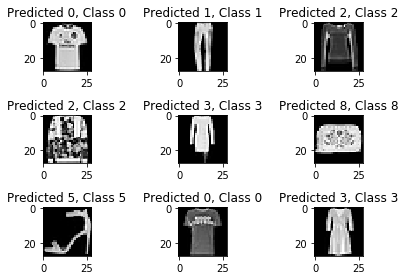

In [51]:
correct = np.where(predicted_classes==test_y)[0]
print ("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct], test_y[correct]))
    plt.tight_layout()

Found 805 incorrect labels


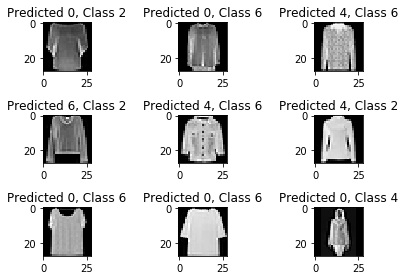

In [52]:
incorrect = np.where(predicted_classes!=test_y)[0]
print ("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test[incorrect].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect], test_y[incorrect]))
    plt.tight_layout()

## Classification Report
Classification report will help you in identifying the misclassified classes in more detail. You will be able to observe for which class the model performed bad out of the given ten classes.



In [53]:
from sklearn.metrics import classification_report
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(test_y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.76      0.91      0.83      1000
     Class 1       0.99      0.98      0.99      1000
     Class 2       0.93      0.85      0.89      1000
     Class 3       0.94      0.92      0.93      1000
     Class 4       0.89      0.90      0.90      1000
     Class 5       0.99      0.97      0.98      1000
     Class 6       0.83      0.75      0.79      1000
     Class 7       0.95      0.96      0.96      1000
     Class 8       0.98      0.98      0.98      1000
     Class 9       0.96      0.96      0.96      1000

   micro avg       0.92      0.92      0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

